<a href="https://colab.research.google.com/github/DwiAyuniRohana/data-science-2025/blob/main/Pertemuan4_DwiAyuni_250401020173.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Dwi Ayuni Rohana  
**NIM:** 250401020173  
**Prodi:** Informatika


===== INFORMASI DATASET =====
Shape Dataset : (150, 5)

===== TIPE DATA =====
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

===== 5 DATA TERATAS =====
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

===== STATISTIK DESKRIPTIF =====
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1

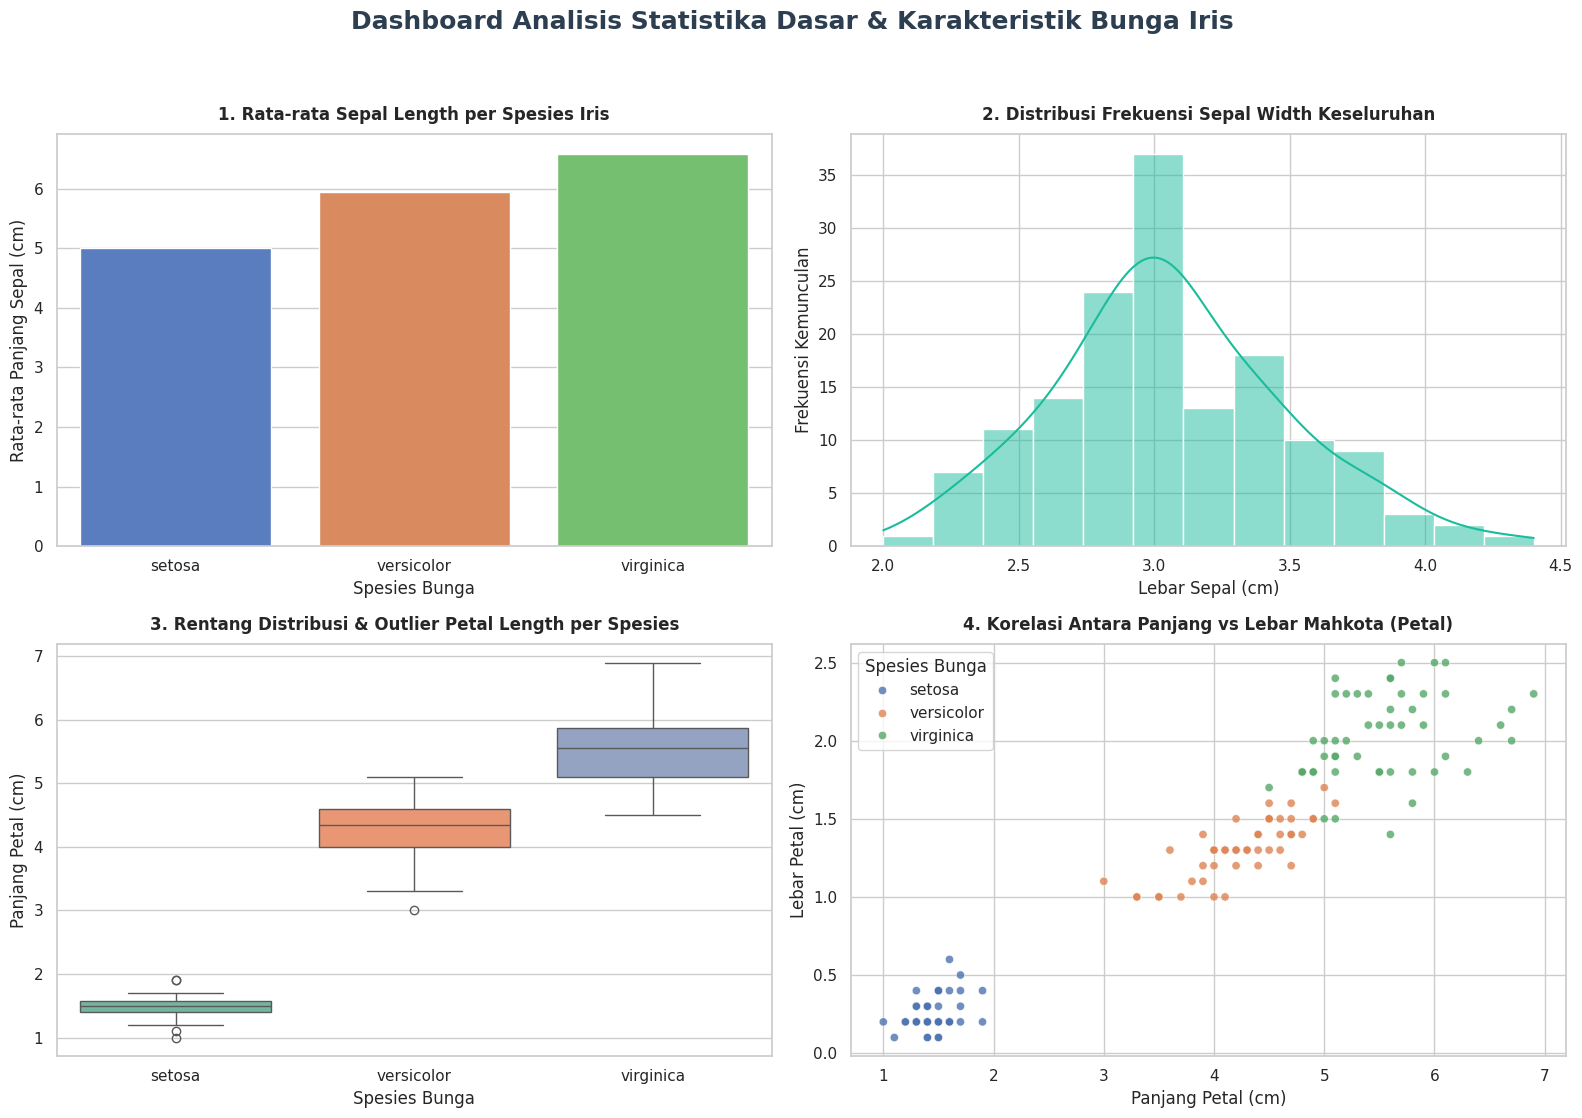

In [2]:
# ==============================================================================
# PERTEMUAN 4 - STATISTIKA DASAR & ANALISA DATA (SKRIP UTUH & KOMPLIT)
# Dataset Iris
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Menonaktifkan peringatan kosmetik agar output terlihat bersih dan profesional
warnings.filterwarnings('ignore', category=FutureWarning)

# Mengatur tema visualisasi dasar (Kompatibel dengan Seaborn v0.13+)
sns.set_theme(style='whitegrid')


# ==============================================================================
# LANGKAH 1 : LOAD & INSPECT DATASET
# ==============================================================================
# Memuat dataset iris resmi bawaan dari pustaka Seaborn
df = sns.load_dataset('iris')

print("===== INFORMASI DATASET =====")
print("Shape Dataset :", df.shape)

print("\n===== TIPE DATA =====")
print(df.dtypes)

print("\n===== 5 DATA TERATAS =====")
print(df.head())

print("\n===== STATISTIK DESKRIPTIF =====")
print(df.describe().round(3))


# ==============================================================================
# LANGKAH 2 : ANALISIS STATISTIKA LANJUTAN (KORELASI)
# ==============================================================================
print("\n===== MATRIKS KORELASI ANTAR FITUR NUMERIK =====")
# Menggunakan numeric_only=True untuk mencegah error pada kolom teks 'species'
matriks_korelasi = df.corr(numeric_only=True)
print(matriks_korelasi.round(3))
print("-" * 60)


# ==============================================================================
# LANGKAH 3 : ARSITEKTUR DASHBOARD VISUALISASI DATA (Grid 2x2)
# ==============================================================================
# Membuat bingkai grid 2 baris dan 2 kolom untuk menampung seluruh gambar grafik
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# Memberikan judul utama di bagian paling atas dashboard
fig.suptitle('Dashboard Analisis Statistika Dasar & Karakteristik Bunga Iris',
             fontsize=18, fontweight='bold', y=0.96, color='#2c3e50')

# ------------------------------------------------------------------------------
# GRAFIK 1 (Kiri Atas): Bar Plot - Rata-rata Panjang Kelopak (Sepal Length) per Spesies
# ------------------------------------------------------------------------------
avg_sepal = df.groupby('species', observed=False)['sepal_length'].mean().reset_index()
# PERBAIKAN: Menyertakan hue='species' dan legend=False agar bebas warning/error
sns.barplot(data=avg_sepal, x='species', y='sepal_length', hue='species',
            palette='muted', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('1. Rata-rata Sepal Length per Spesies Iris', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Spesies Bunga')
axes[0, 0].set_ylabel('Rata-rata Panjang Sepal (cm)')

# ------------------------------------------------------------------------------
# GRAFIK 2 (Kanan Atas): Histogram & KDE - Distribusi Lebar Kelopak (Sepal Width)
# ------------------------------------------------------------------------------
sns.histplot(data=df, x='sepal_width', kde=True, color='#1abc9c', ax=axes[0, 1])
axes[0, 1].set_title('2. Distribusi Frekuensi Sepal Width Keseluruhan', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Lebar Sepal (cm)')
axes[0, 1].set_ylabel('Frekuensi Kemunculan')

# ------------------------------------------------------------------------------
# GRAFIK 3 (Kiri Bawah): Boxplot - Rentang Nilai Petal Length Berdasarkan Spesies
# ------------------------------------------------------------------------------
# PERBAIKAN: Memasangkan hue='species' untuk memisahkan distribusi kelompok secara aman
sns.boxplot(data=df, x='species', y='petal_length', hue='species',
            palette='Set2', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Rentang Distribusi & Outlier Petal Length per Spesies', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Spesies Bunga')
axes[1, 0].set_ylabel('Panjang Petal (cm)')

# ------------------------------------------------------------------------------
# GRAFIK 4 (Kanan Bawah): Scatter Plot - Hubungan Petal Length vs Petal Width
# ------------------------------------------------------------------------------
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species',
                palette='deep', alpha=0.8, ax=axes[1, 1])
axes[1, 1].set_title('4. Korelasi Antara Panjang vs Lebar Mahkota (Petal)', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Panjang Petal (cm)')
axes[1, 1].set_ylabel('Lebar Petal (cm)')
axes[1, 1].legend(title='Spesies Bunga')


# ==============================================================================
# LANGKAH 4 : SENTUHAN AKHIR TATA LETAK GRAPHIC
# ==============================================================================
# Mengatur jarak otomatis antar grafik agar teks judul dan label tidak saling bertabrakan
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Menampilkan keseluruhan dashboard gambar grafik secara utuh
plt.show()

# Kesimpulan

Pada praktikum ini saya mempelajari cara melakukan eksplorasi awal data (Data Inspection) dan statistika deskriptif menggunakan Python, Pandas, dan Seaborn pada dataset Iris. Proses yang dilakukan meliputi memuat dataset, melihat ukuran data, memeriksa tipe data setiap kolom, menampilkan beberapa data awal, serta menghitung statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dan standar deviasi.

Temuan utama dari eksplorasi awal menunjukkan bahwa dataset Iris terdiri dari 150 baris data dengan 5 kolom, yaitu empat fitur numerik (sepal length, sepal width, petal length, dan petal width) serta satu kolom kategorikal (species). Selain itu, statistik deskriptif memberikan gambaran umum mengenai persebaran dan karakteristik setiap fitur sehingga memudahkan proses analisis lebih lanjut.

Keterbatasan pada tahap ini adalah analisis masih bersifat deskriptif dan belum mencakup visualisasi data, pengujian statistik, maupun pembangunan model machine learning. Pertanyaan yang muncul adalah apakah terdapat perbedaan yang signifikan antara masing-masing spesies Iris berdasarkan karakteristik ukuran sepal dan petal yang dimiliki.